In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import TimeTagger as tt
import os

## Countrate Calibration
Calibrate countrates. Live monitor of counts-per-second.

* Uses ```tt.Countrate``` measurement class instance from swabian. 

In [ ]:
# Experimental Parameters
SPAD_A_CH = 1           # Port in Swabian for SPAD A
SPAD_B_CH = 2           # Port in Swabian for SPAD B
LASER_SYNC = 3
ADQ_TIME_PS = int(5e11) # In pico-seconds

# Countrate Experiment
tagger = tt.createTimeTagger()
tagger.setTriggerLevel(3, +0.5) #Laser sync trigger voltage
cr = tt.Countrate(tagger, channels=[SPAD_A_CH, SPAD_B_CH, LASER_SYNC]) # measurement class

# getSerial() is a nice trick to verify you are talking to the right machine
print(f"Connected to Swabian SN: {tagger.getSerial()}\nStarting Count Rate Monitor...")
print("(Press the 'Stop/Interrupt Kernel' button in Jupyter to exit)\n")

# Initialize list to store countrates
rates_A = []
rates_B = []
rates_LASER = []

try: 
    while True: 
        # clear=True guarantees we only look at the photons inside this specific 0.5s window
        cr.startFor(ADQ_TIME_PS, clear=True)    
        cr.waitUntilFinished()
        # Call measurement object > array 
        rates = cr.getData()
        # Separate rates for chanel A and B
        rate_A = rates[0]
        rate_B = rates[1]
        rate_LASER = rates[2]
        # Append to list
        rates_A.append(rate_A)
        rates_B.append(rate_B)
        rates_LASER.append(rate_LASER)
        # Live monitor 
        print(f"\r[LIVE] SPAD A: {rate_A:,.3f} cps  |  SPAD B: {rate_B:,.3f} cps | LASER Sync: {rate_LASER:,.3f} cps  ", end="", flush=True)

except KeyboardInterrupt:
    print("\n\nHalting Monitor...")
    rates_A_np = np.array(rates_A)
    rates_B_np = np.array(rates_B)
    rates_LASER_np = np.array(rates_LASER)
    if len(rates_A_np) > 0:
        mean_A = np.mean(rates_A_np)
        mean_B = np.mean(rates_B_np)
        mean_LASER = np.mean(rates_LASER)
        print(f"--- MEAN CPS OF {len(rates_A_np)} SAMPLES ---")
        print(f"Mean SPAD A: {mean_A:,.3f} cps")
        print(f"Mean SPAD B: {mean_B:,.3f} cps")
        print(f"Mean LASER: {mean_LASER:,.3f}cps")
        print("---------------------------------------")

finally: # Free hardware
    tt.freeTimeTagger(tagger)
    print("Hardware Released.")

Connecting to Time Tagger...
Connected to Swabian SN: 2440001E7R
Starting Count Rate Monitor...
(Press the 'Stop/Interrupt Kernel' button in Jupyter to exit)

[LIVE] SPAD A: 1,223,316.000 cps  |  SPAD B: 1,122,102.000 cps | LASER Sync: 19,999,826.000 cps  

Halting Monitor...
--- FINAL STATISTICS (14 samples) ---
Mean SPAD A: 1,225,345.857 cps
Mean SPAD B: 1,123,685.429 cps
Mean LASER: 19,999,826.000cps
---------------------------------------
Hardware Released.


# COINCIDENCE MEASUREMENTS (PLAN 2)

Connecting to Time Tagger...
Acquiring G2 histogram for 1.0 seconds...


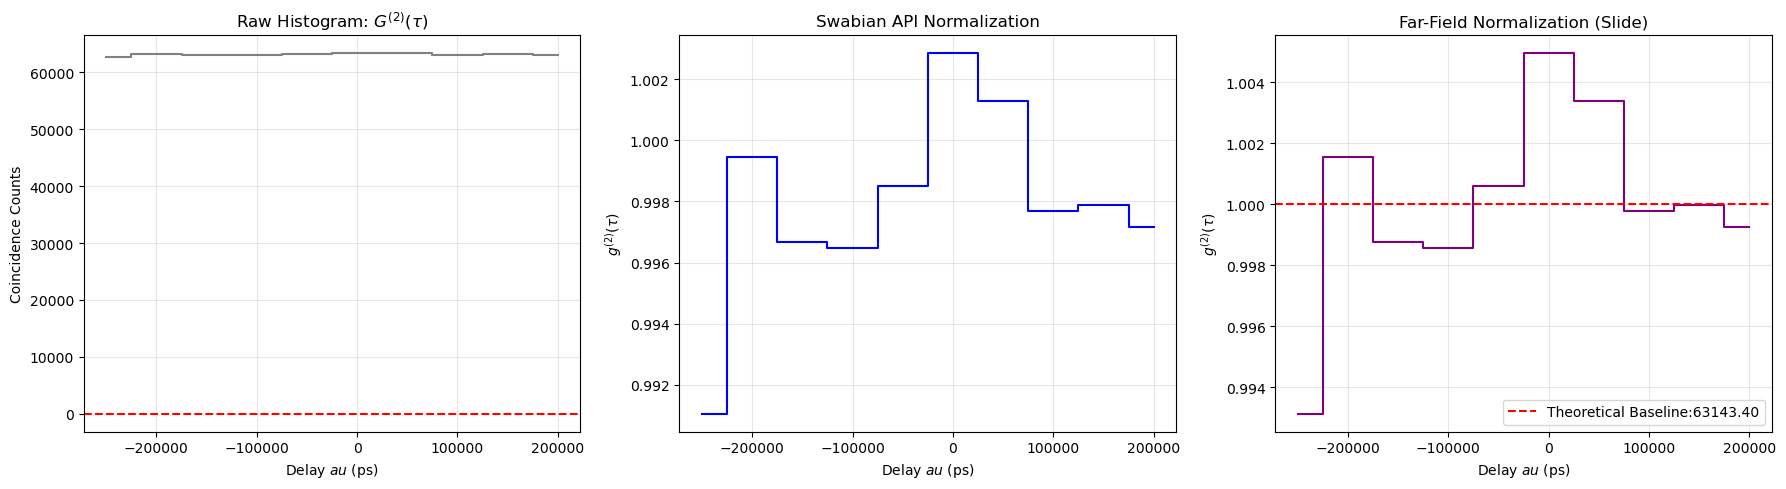

In [ ]:
import TimeTagger as tt
import numpy as np
import matplotlib.pyplot as plt

# Measurement Parameters
ch_ref = 1
ch_sig = 2
bin_width_ps = 50000 #12500#1000000   # 50 ps resolution
n_bins = 10      # enough +/- window to ensure we see the "far from tau=0" baseline
exposure_time = 1e12 # pico seconds

print("Connecting to Time Tagger...")
tagger = tt.createTimeTagger()
tagger.setInputDelay(ch_ref, -4280 + 4280/2) # Add setInputDelay here based on previous calibrations. 

# Measure Correlation
print(f"Acquiring G2 histogram for {exposure_time/1e12} seconds...")
corr = tt.Correlation(tagger, ch_ref, ch_sig, binwidth=bin_width_ps, n_bins=n_bins)

corr.startFor(exposure_time, clear=True)
corr.waitUntilFinished()

# Extract Data
lags = corr.getIndex()                 # Time axis in picoseconds
G2_raw = corr.getData()                # Raw coincidence counts
g2_swabian = corr.getDataNormalized()  # Swabian's hardware normalization

tt.freeTimeTagger(tagger)

# Far Field Normalization
far_field_limit = 0.8 * np.min(lags) # Select time bins "far from tau = 0".
baseline_mask = (np.abs(lags) > far_field_limit)
baseline_avg = np.mean(G2_raw[baseline_mask]) # Calculate the average count for far bins
g2_manual = G2_raw / baseline_avg # Normalize

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Raw Unnormalized G2 (The actual photon counts)
axes[0].plot(lags, G2_raw, drawstyle='steps-mid', color='gray')
axes[0].axhline(1.0, color='red', linestyle='--', label=f'Theoretical Baseline:{baseline_avg:.2f}')
axes[0].set_title(r"Raw Histogram: $G^{(2)}(\tau)$")
axes[0].set_xlabel("Delay $\tau $ (ps)")
axes[0].set_ylabel("Coincidence Counts")
axes[0].grid(True, alpha=0.3)

# Plot 2: Swabian Hardware Normalization
axes[1].plot(lags, g2_swabian, drawstyle='steps-mid', color='blue')
axes[1].set_title(r"Swabian API Normalization")
axes[1].set_xlabel("Delay $\tau $ (ps)")
axes[1].set_ylabel(r"$g^{(2)}(\tau)$")
axes[1].grid(True, alpha=0.3)

# Plot 3: Manual Far-Field Normalization (Slide Method)
axes[2].plot(lags, g2_manual, drawstyle='steps-mid', color='purple')
axes[2].axhline(1.0, color='red', linestyle='--', label=f'Theoretical Baseline:{baseline_avg:.2f}')
axes[2].set_title(r"Far-Field Normalization (Slide)")
axes[2].set_xlabel("Delay $\tau $ (ps)")
axes[2].set_ylabel(r"$g^{(2)}(\tau)$")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save Data

In [ ]:
# Locate data path
save_dir = "../data/raw/correlation_2ch"
#os.makedirs(save_dir, exist_ok=True) # Failsafe to ensure the folder exists

# Select name for data
source_type = "pulsed_20MHz_1200kcps"
#source_type = "LabLight_2000kcps"

filename = f"{save_dir}/g2_tau_{source_type}.npz"
print(f"Saving data to {filename}...")
np.savez(
    filename,
    lags=lags,
    G2_raw=G2_raw,
    g2_swabian=g2_swabian,
    g2_manual=g2_manual,
    bin_width_ps=bin_width_ps,
    exposure_time_ps=exposure_time
)

Saving data to ../data_coincidence_meas/g2_tau_measurement_Pulsed_20MHz_1200kcps_bin=50000ps.npz...
Data saved


## DATA ANALYSIS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Loading data from ../data_coincidence_meas/g2_tau_measurement_Pulsed_20MHz_1200kcps_bin=50000ps.npz...


C:\Users\Eng Barroso\AppData\Local\Temp\ipykernel_14068\1706747492.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


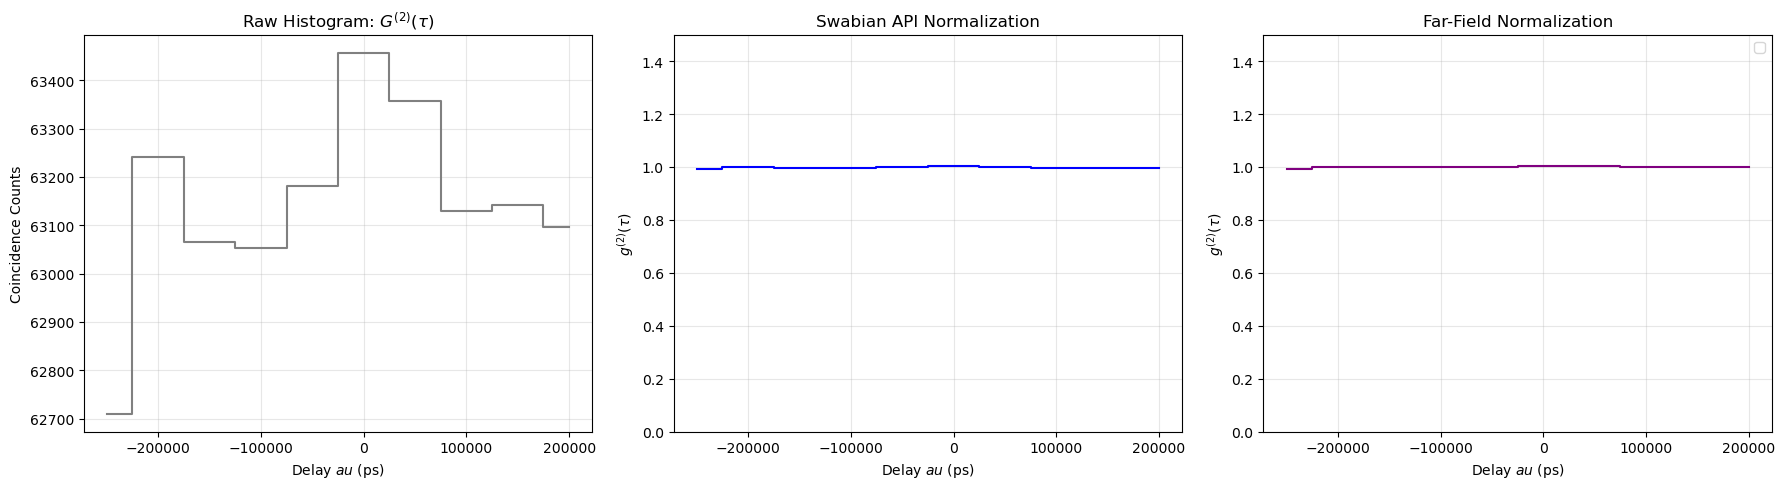

In [ ]:
# Locate file path 
data_folder = "../data/raw/correlation_2ch"
filename = f"{data_folder}/g2_tau_pulsed640nm_80MHz.npz"
#filename = f"{data_folder}/g2_tau_measurement_Pulsed_1MHz_bin=10ps.npz"
#filename = f"{data_folder}/g2_tau_measurement_Pulsed_1MHz_2000kcps_bin=1000000ps.npz"
#filename = f"{data_folder}/g2_tau_measurement_Pulsed_80MHz_700kcps_bin=12500ps.npz"
#filename = f"{data_folder}/g2_tau_measurement_LabLight_1000kcps_bin=10ps.npz"
#filename = f"{data_folder}/g2_tau_measurement_ThermalLamp_1000kcps_bin=10ps.npz"
#filename = f"{data_folder}/g2_tau_measurement_Pulsed_20MHz_1200kcps_bin=50000ps.npz"

# Load Data
print(f"Loading data from {filename}...")
with np.load(filename) as data:
    lags = data['lags']
    G2_raw = data['G2_raw']
    g2_swabian = data['g2_swabian']
    g2_manual = data['g2_manual']
    # You can also extract bin_width_ps and exposure_time_ps here if needed for titles

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(lags, G2_raw, drawstyle='steps-mid', color='gray') #1: Unnormalized G2
axes[0].set_title(r"Raw Histogram: $G^{(2)}(\tau)$")
axes[0].set_xlabel("Delay $\tau$ (ps)")
axes[0].set_ylabel("Coincidence Counts")
axes[0].grid(True, alpha=0.3)
axes[1].plot(lags, g2_swabian, drawstyle='steps-mid', color='blue') #2: Swabian Normalization
axes[1].set_title(r"Swabian API Normalization")
axes[1].set_xlabel("Delay $\tau$ (ps)")
axes[1].set_ylabel(r"$g^{(2)}(\tau)$")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0,1.5)
axes[2].plot(lags, g2_manual, drawstyle='steps-mid', color='purple') # 3:Far-Field Normalization
#axes[2].axhline(1.0, color='red', linestyle='--', label='Far Field Average')
axes[2].set_title(r"Far-Field Normalization")
axes[2].set_xlabel("Delay $\tau$ (ps)")
axes[2].set_ylabel(r"$g^{(2)}(\tau)$")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0,1.5)

plt.tight_layout()
plt.show()